In [4]:
import matplotlib.pyplot as plt
import scienceplots
import math
import numpy as np

def calculate_inclined_positions(angle_deg=10):
    """
    计算小方块在10度斜面上的位置
    
    参数:
    angle_deg: 斜面角度(度)
    """
    # 角度转换为弧度
    angle_rad = math.radians(angle_deg)
    
    # 当前参数
    ground_height = 0.5  # 地面几何中心z坐标
    ground_thickness = 1  # 地面厚度
    cube_size = 1         # 小方块尺寸
    sphere_radius = 0.1   # 小球半径
    
    # 计算斜面位置
    # 斜面绕x轴旋转10度，保持地面顶部与原点相切
    ground_pe = [0, 0, ground_height, 0, -angle_rad, 0]  # [x,y,z,rx,ry,rz]
    
    # 计算小方块位置
    # 小方块应该放在斜面上，底部四个小球与斜面接触
    cube_height = ground_height + (cube_size + ground_thickness) * 0.5 / math.cos(angle_rad)
    # cube_z_offset = sphere_radius + (cube_size/2 - 0.4)  # 考虑小球半径和几何偏移
    # cube_height = cube_z_offset + (cube_size/2) * math.sin(angle_rad)
    
    # 小方块的位置和姿态
    cube_pe = [0, 0, cube_height, 0, -angle_rad, 0]
    
    return ground_pe, cube_pe

  # import sys
  # sys.path.append("D:/code/sire/install/python/debug")
import sire
cs = sire.ControlServer.instance()
model = cs.model()
model.addSolvers()
middleware = cs.addSireMiddleware()
simulator = middleware.simulationLoop()
simulator.simDuration = 0.6
simulator.setEventHandlerMap({0:6, 1:7, 2:8})
physicsEngine = middleware.physicsEngine()
contactSolver = physicsEngine.addContactPositionForceSolver()
physicsEngine.collisionDetectionFlag = True
physicsEngine.contactSolverFlag = True
contactSolver.setDefaultProp("{k:1.4e8,d:10000,cr:0.2}")
# contactSolver.setDefaultProp("{k:2e7,d:10000,cr:0.2}")
contactSolver.addMaterialPair("m1", "m1", "{k:2e8,d:10000,cr:0,cof:0.3,threshold_velocity:2e-6}")
# contactSolver.addMaterialPair("m1", "m2", "{k:2e8,d:150000,cr:0.3,cof:0.5,threshold_velocity:1e-4}")
model.setGravity([0, 0, -9.81, 0, 0, 0])
model.ground().addMarker("joint_0_k")
model.ground().addMarker("ground_marker")
ground_pe, cube_pe = calculate_inclined_positions(15)
ground_pm = sire.pe3132tfmatrix(ground_pe).tolist()
model.ground().addBoxGeometry(0, 100, 100, 1, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
model.ground().addBoxGeometry(0, 5, 5, 1, ground_pm)

physicsEngine.addBoxGeometry(100, 100, 1, 0, False, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
physicsEngine.addBoxGeometry(5, 5, 1, 0, False, ground_pm)
# sliderPrt = model.addPartByPe(ground_pe, "313", [10, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
# model.link(1).addMarker("slider_center")
boxPrt = model.addPartByPe(cube_pe, "313", [1, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
model.link(1).addMarker("box_center")
model.init()
boxPrt.addBoxGeometry(boxPrt.id, 1.0, 1.0, 1.0, prt_pm=[1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1])
boxPrt.cptGeometryInertial2Part(1)
boxPrt.vs = sire.vp2vs(cube_pe[:3], [0, -2 * math.cos(math.radians(15)), 2 * math.sin(math.radians(15))])

physicsEngine.addBoxGeometry(1, 1, 1, boxPrt.id, True)
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
print(sire.toXmlString(cs))
cs.init()
for i in range(4):
  physicsEngine.collisionFilter().enableCollisionPair(1, i + 3)

physicsEngine.collisionFilter().saveMatConfig()

count = 0
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  sim_time = simulator.simTime()
  if abs(sim_time - 0.37) < 1e-8 and count == 0:
    print(boxPrt.getAs())
    count += 1
  simulator.step(1, False)

simulator.recordsContactCptInfo()
displayInitJson = model.displayInitJson()
result = simulator.recordsToJson()
print("Simulation finished, records loaded")
import meshcat
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/web_interface/public"
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
sire.animateRobotByRecords(model.numLinks(), result, 1000, vis)
cs.clear()
vis.jupyter_cell()

<ControlServer>
    <Model __prop_name__="model" name="object" time="0">
        <Environment __prop_name__="environment" gravity="{0,0,-9.81,0,0,0}"/>
        <VariablePoolElement __prop_name__="variable_pool"/>
        <PartPoolElement __prop_name__="part_pool">
            <Part name="ground" active="true" pe="{0,0,0,-0,0,-0}" vel="{0,0,0,0,0,0}" acc="{0,0,0,0,0,0}" inertia="{1,0,0,0,1,1,1,0,0,0}">
                <MarkerPoolElement __prop_name__="marker_pool">
                    <Marker name="joint_0_k" active="true" pe="{0,0,0,-0,0,-0}"/>
                    <Marker name="ground_marker" active="true" pe="{0,0,0,-0,0,-0}"/>
                </MarkerPoolElement>
                <GeometryPoolElement __prop_name__="geometry_pool">
                    <BoxGeometry id="0" pm="{1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1}" part_id="0" is_dynamic="true" side="{100,100,1}"/>
                    <BoxGeometry id="1" pm="{1,-0,0,0,0,0.965925826289068,0.258819045102521,0,-0,-0.258819045102521,0.9659258

0.0 0.001


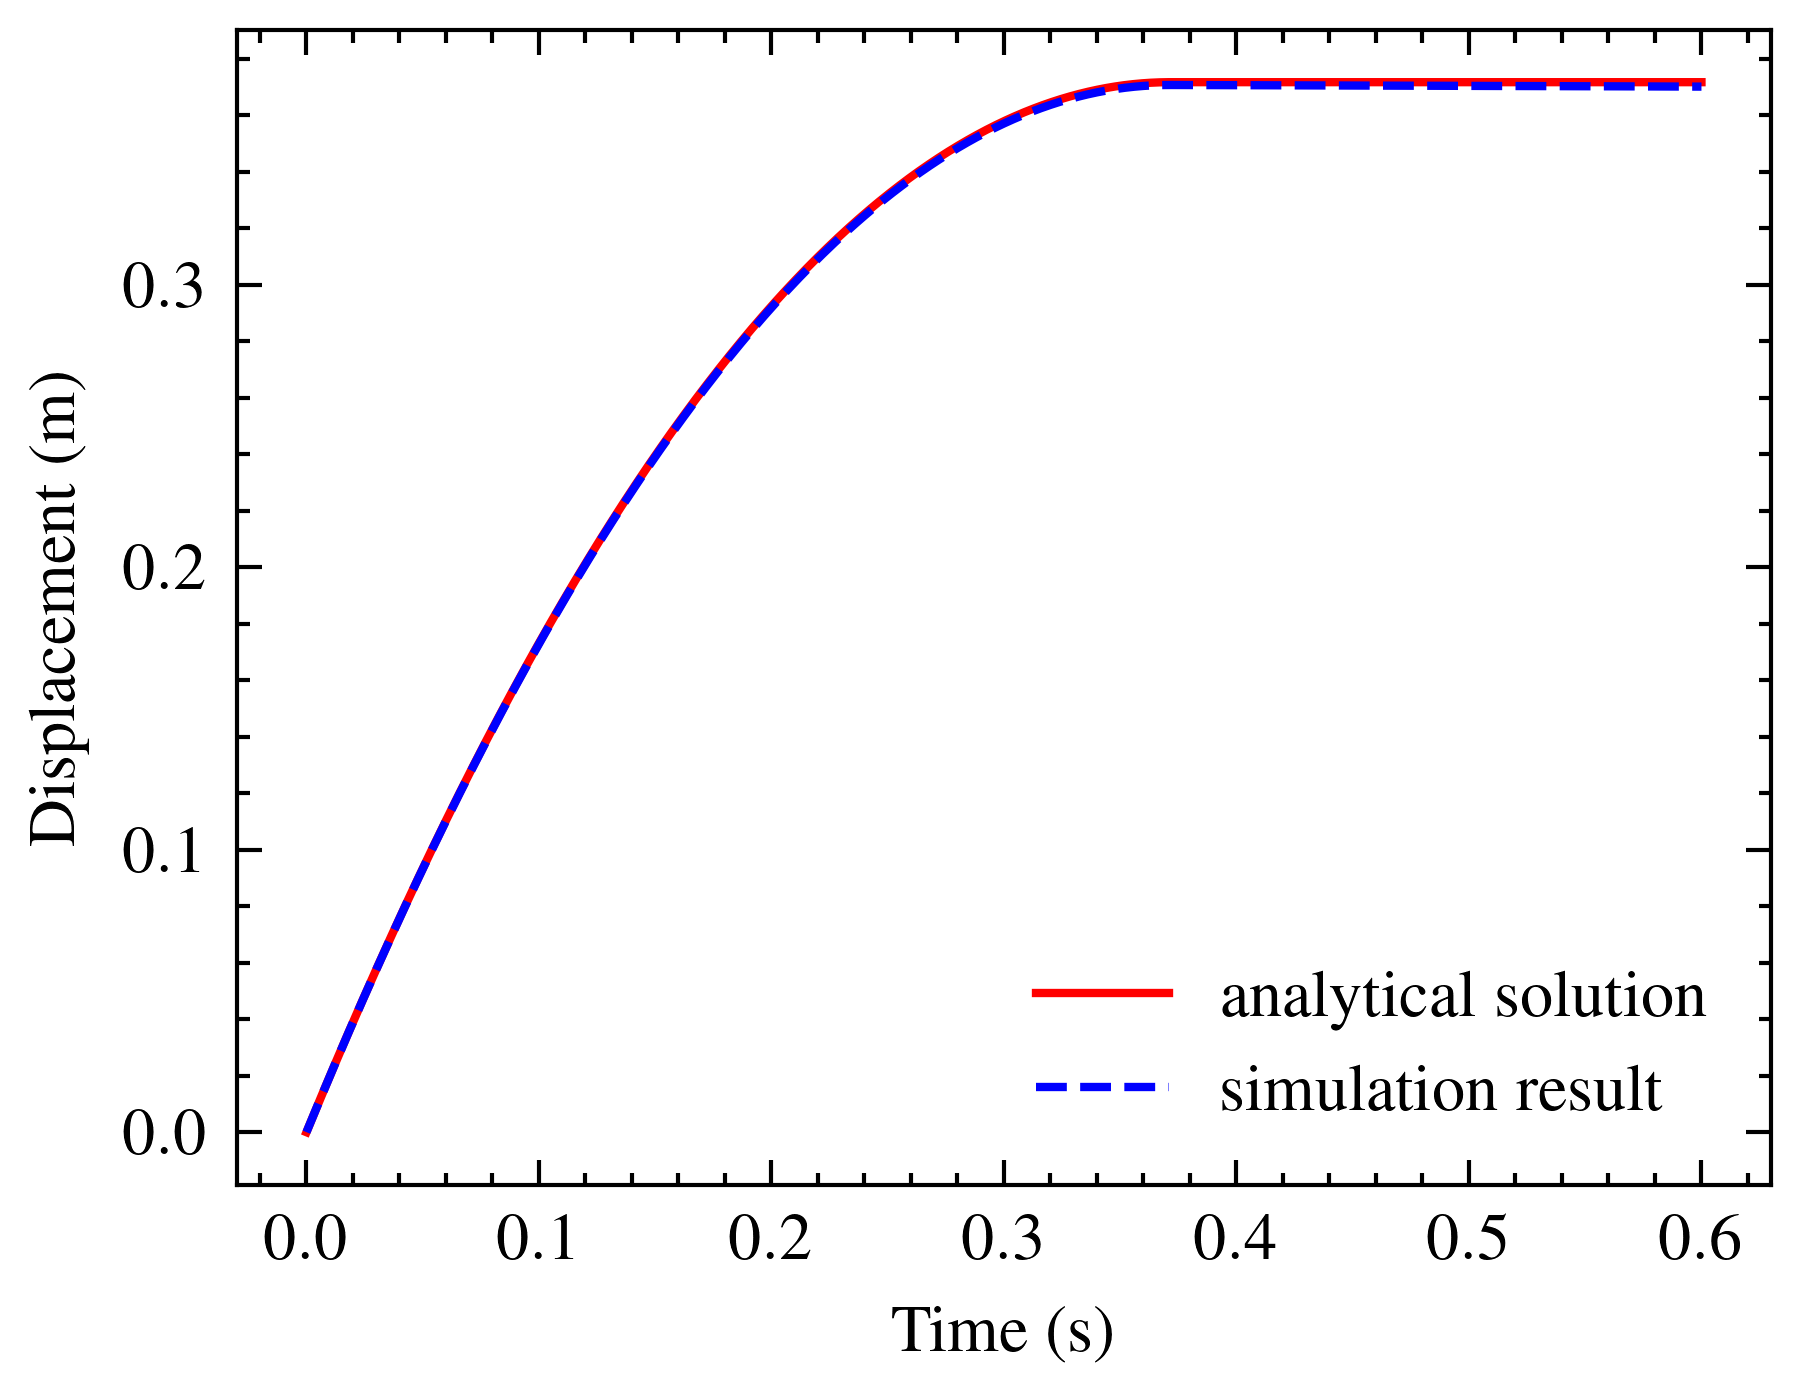

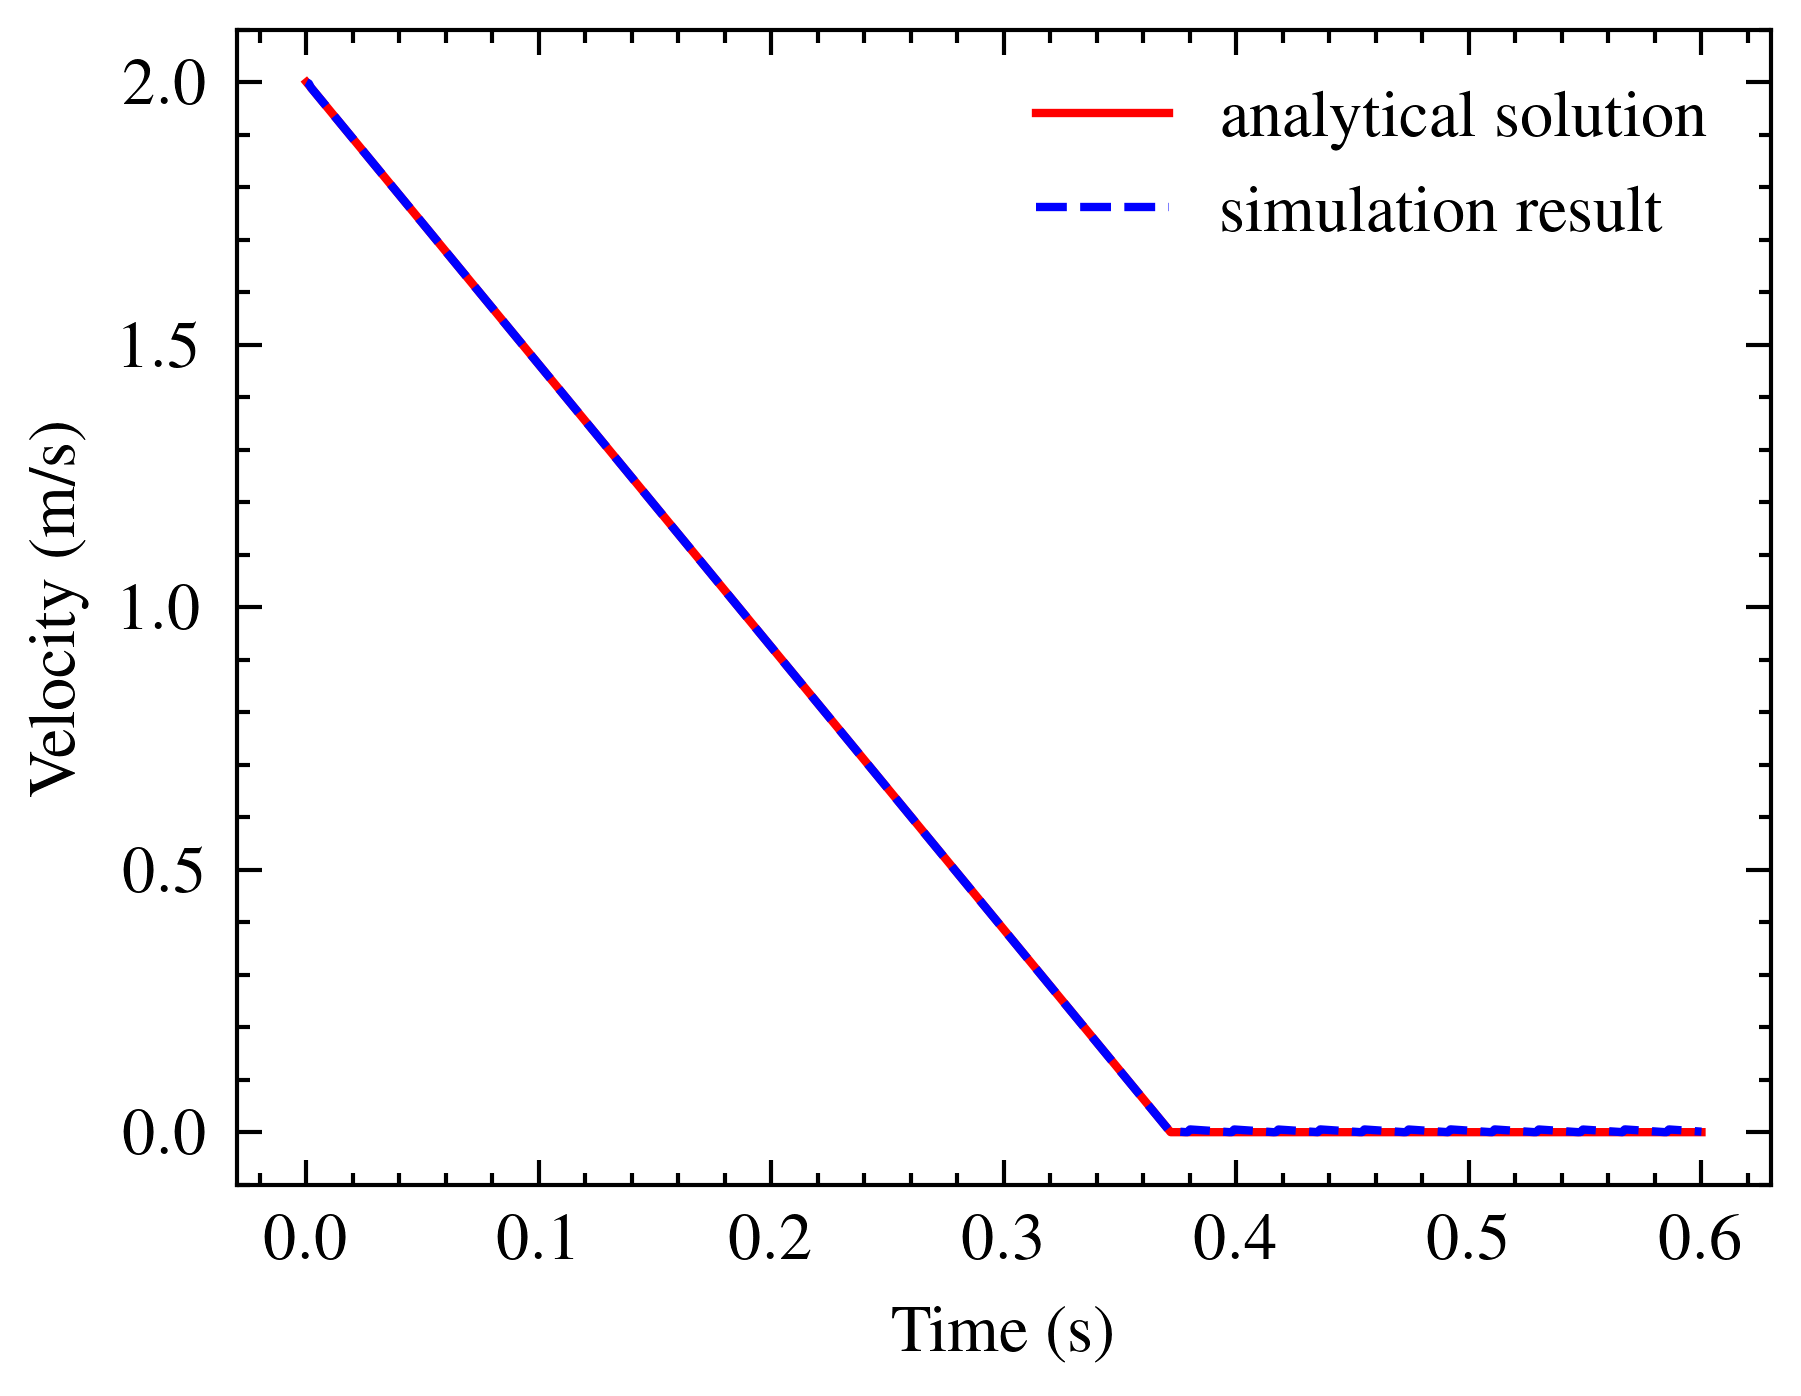

In [6]:
import numpy as np
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []
yv = []

lowerBound = sire.binarySearch(timeIndices, 0)
upperBound = sire.binarySearch(timeIndices, 0 + 0.6)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  pm = sire.pq2tfmatrix(partpq[i][1])
  yOffset = pm[1, 3]
  zOffset = (pm[2, 3] - cube_pe[2])
  y.append(math.sqrt(yOffset ** 2 + zOffset ** 2))  # z position from transformation matrix
  yv.append(math.sqrt(partvs[i][1][2] ** 2 + partvs[i][1][1]**2))  # z velocity

t = 2 / (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15)))
xt = 2 * t - 0.5 * (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * t ** 2
x2 = np.linspace(0, 0.6, 10000)
y2 = np.piecewise(x2, 
                 [x2 <= t, x2 > t], 
                 [lambda x: 2 * x - 0.5 * (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * x ** 2, lambda x: xt])
with plt.style.context(['science','ieee']):
  plt.plot(x2, y2, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, y, color='blue', linestyle="--", label="simulation result")
  plt.legend()
  plt.xlabel("Time (s)")
  plt.ylabel("Displacement (m)")
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data2.pdf", format="pdf")
  plt.show()

  x1 = np.linspace(0, 0.6, 10000)
  y1 = np.piecewise(x1, 
                   [x1 < t, x1 >= t], 
                   [lambda x: 2 - (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * x, lambda x: 0])
  plt.plot(x1, y1, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, yv, color='blue', linestyle="--", label="simulation result")
  plt.xlabel("Time (s)")
  plt.ylabel("Velocity (m/s)")
  plt.legend()
  plt.show()

0.3700000000000003 0.3710000000000003
0.3700000000000003 [6.547936570695764e-10, 5.198356381668794, -1.3928953944373237] [6.547936549979522e-10, 5.198356381668794, -1.3928953944373237, 1.046517318509385e-15, -2.2062489274137496e-10, -8.237774109920162e-10]
0.3700000000000003 [-1.3846415006816422e-16, -0.008459791360684837, 0.0022667942632312865]
0.3710000000000003 [-6.549858128685337e-10, 5.198356381668799, -1.3928953944373181] [-6.549829341668829e-10, 5.198356381668799, -1.3928953944373181, 2.616289227781067e-15, 2.207383413525284e-10, 8.237892615726361e-10]
0.3710000000000003 [6.546551908478841e-13, -0.0032614349790160433, 0.0008738988687939629]
0.3720000000000003 [6.55185535842076e-10, -0.2933563816688346, 0.07860460556266093] [6.551855363982203e-10, -0.2933563816688346, 0.07860460556266093, -1.206764520796559e-14, -2.2086926069183103e-10, -8.237517860812003e-10]
0.3720000000000003 [-3.277433189988845e-16, 0.001936921402652756, -0.0005189965256433553]
0.3730000000000003 [-6.54974817

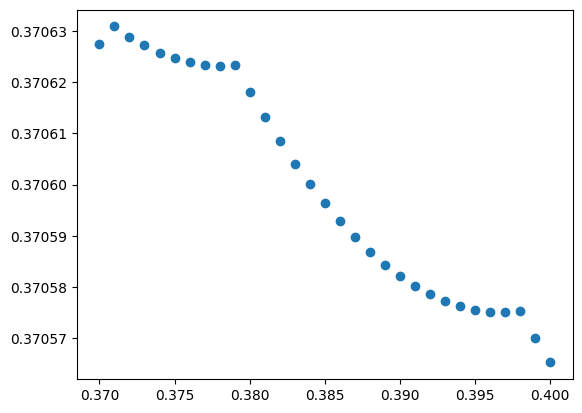

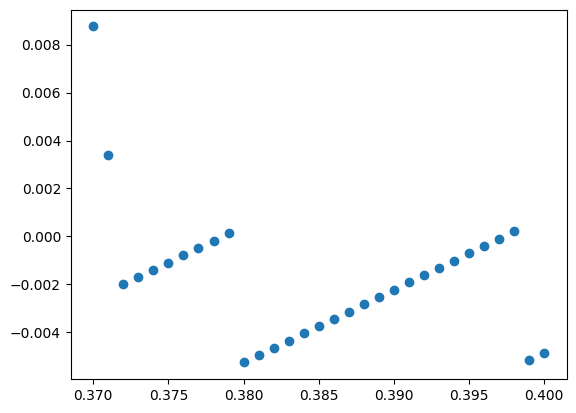

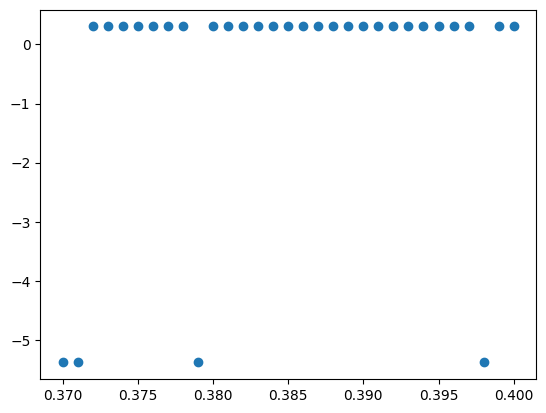

In [ ]:
x = []
y = []
yv = []
ya = []

lowerBound = sire.binarySearch(timeIndices, 0.37)
upperBound = sire.binarySearch(timeIndices, 0.4)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  pm = sire.pq2tfmatrix(partpq[i][1])
  yOffset = pm[1, 3]
  zOffset = (pm[2, 3] - cube_pe[2])
  y.append(math.sqrt(yOffset ** 2 + zOffset ** 2))  # z position from transformation matrix
  vp = sire.vs2vp(partpq[i][1], partvs[i][1], [0, 0, 0])
  v = math.sqrt(vp[2] ** 2 + vp[1] ** 2)
  ap = sire.as2ap(partpq[i][1], partvs[i][1], partas[i][1], [0, 0, 0])
  a = math.sqrt(ap[2] ** 2 + ap[1] ** 2)
  yv.append(v if vp[2] > 0 else -v)  # z velocity
  ya.append(a if ap[2] > 0 else -a)  # z velocity
  print(timeIndices[i], ap, partas[i][1])
  print(timeIndices[i], vp)
plt.scatter(x, y)

# plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data2.pdf", format="pdf")
plt.show()

plt.scatter(x, yv)
plt.show()
plt.scatter(x, ya)

0.3716273973424585
-0.30370487431299953
2.5390148324557287


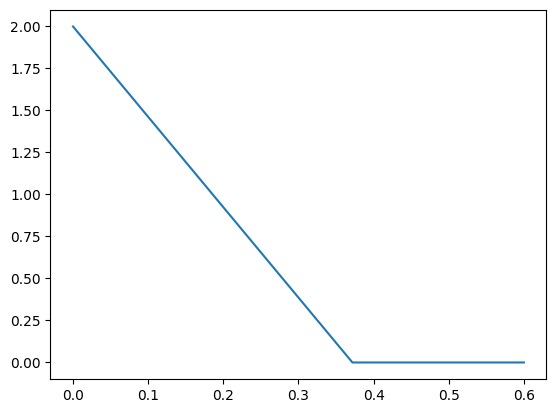

In [ ]:
print(2 / (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))))
print(9.81 * math.sin(math.radians(15)) - 0.3 * 9.81 * math.cos(math.radians(15)))
print(9.81 * math.sin(math.radians(15)))
t = 2 / (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15)))

x1 = np.linspace(0, 0.6, 10000)
y1 = np.piecewise(x1, 
                 [x1 < t, x1 >= t], 
                 [lambda x: 2 - (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * x, lambda x: 0])
plt.plot(x1, y1)